Removed no burn in
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in
Removed no burn in
Saved: /home/geng/Codes/sgl_cosmo/jax01/joint_plots/w0wa_sgl_planckbao_desi.png


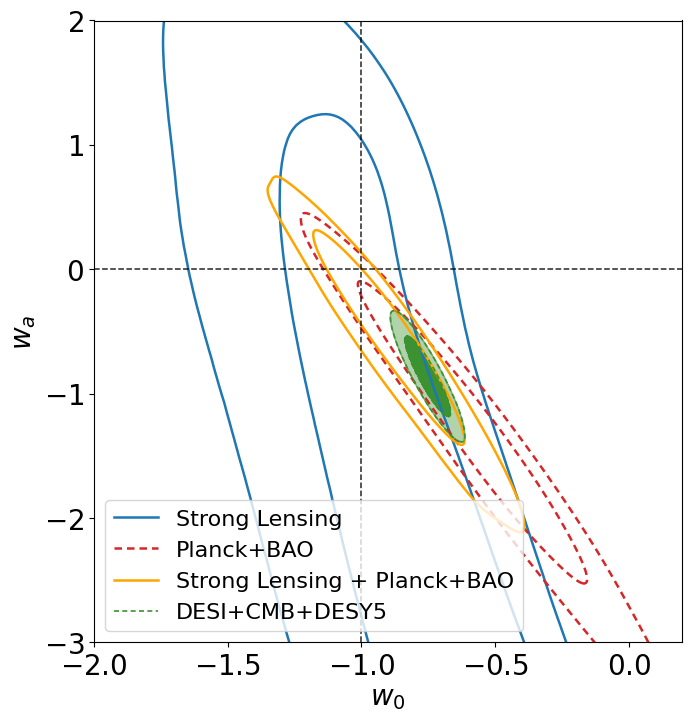

In [2]:
# w0-wa overlay using local SL npz + Planck+BAO + DESI+CMB+DESY5
import os
import numpy as np
from scipy.stats import gaussian_kde
from getdist.mcsamples import MCSamples, loadMCSamples
from getdist import plots

# ---------------- local SL from npz (keep omegam,w0,wa) ----------------
npz_path = '/home/geng/Codes/sgl_cosmo/jax01/output/posterior_minimal_chunks_sgl140_w0wa_main_accept0.97.npz'
if not os.path.exists(npz_path):
    raise FileNotFoundError(f'Missing local npz: {npz_path}')

d = np.load(npz_path)
for k in ['Om', 'w0', 'wa']:
    if k not in d:
        raise KeyError(f'NPZ missing key: {k}')

SL = MCSamples(
    samples=np.column_stack([d['Om'], d['w0'], d['wa']]),
    names=['omegam', 'w0', 'wa'],
    labels=[r'\Omega_{\rm m}', r'w_0', r'w_a'],
)
SL.label = r'Strong Lensing'

# ---------------- Planck+BAO root auto-resolve ----------------
planck_base_label = 'base_w_wa'
chain_name = 'plikHM_TTTEEE_lowl_lowE_BAO'
_planck_dir_candidates = [
    '/home/geng/Codes/sgl_cosmo/jax01/data/planck_data',
    '/home/geng/Codes/sgl_cosmo/jax01/data',
    '/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data',
]

def _resolve_planck_root(base_label, chain_name):
    tried = []
    for d0 in _planck_dir_candidates:
        r1 = os.path.join(d0, base_label, chain_name, f'{base_label}_{chain_name}')
        tried.append(r1)
        if os.path.exists(r1 + '_1.txt') or os.path.exists(r1 + '.paramnames'):
            return r1
        r2 = os.path.join(d0, base_label, chain_name)
        tried.append(r2)
        if os.path.exists(r2 + '_1.txt') or os.path.exists(r2 + '.paramnames'):
            return r2
    raise FileNotFoundError('Planck+BAO chain root not found. Tried:\n' + '\n'.join(tried))

planck_root_bao = _resolve_planck_root(planck_base_label, chain_name)
planck_bao = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)

# unify to omegam/w0/wa if needed
P = planck_bao.getParams()
names = {p.name for p in planck_bao.getParamNames().names}
if 'w0' not in names:
    if hasattr(P, 'w'):
        planck_bao.addDerived(P.w, name='w0', label=r'w_0')
    else:
        raise RuntimeError('Planck+BAO chain has no w0/w')
if 'wa' not in names and not hasattr(P, 'wa'):
    raise RuntimeError('Planck+BAO chain has no wa')
if 'omegam' not in names:
    if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
        if hasattr(P, 'h'):
            planck_bao.addDerived((P.ombh2 + P.omch2)/P.h**2, name='omegam', label=r'\Omega_{\rm m}')
        elif hasattr(P, 'H0'):
            planck_bao.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2, name='omegam', label=r'\Omega_{\rm m}')
try:
    planck_bao.setLabel('omegam', r'\Omega_{\rm m}')
    planck_bao.setLabel('w0', r'w_0')
    planck_bao.setLabel('wa', r'w_a')
except Exception:
    pass
planck_bao.label = r'Planck+BAO'

# ---------------- DESI+CMB+DESY5 gaussian approx ----------------
mu_desi = (-0.752, -0.86)   # (w0, wa)
sigma_desi = (0.057, 0.215)
rho_desi = -0.90

def gaussian_to_mcsamples_w0wa(mu, sigmas, rho, nsamp=200000, seed=123, label=r'DESI+CMB+DESY5'):
    rng = np.random.default_rng(seed)
    s0, sa = sigmas
    cov = np.array([[s0**2, rho*s0*sa], [rho*s0*sa, sa**2]], dtype=float)
    samples = rng.multivariate_normal(mean=mu, cov=cov, size=nsamp)
    m = MCSamples(samples=samples, names=['w0','wa'], labels=[r'w_0', r'w_a'])
    m.label = label
    return m

DESI_CMB_DESY5 = gaussian_to_mcsamples_w0wa(mu_desi, sigma_desi, rho_desi)

# ---------------- Joint: reweight in 3D (omegam,w0,wa), plot in 2D (w0,wa) ----------------
_ALIAS = {
    'omegam': ['omegam', 'Om', 'om', 'Omega_m', 'OmegaM', 'omm'],
    'w0': ['w0', 'w', 'w_0'],
    'wa': ['wa', 'w_a', 'wprime', 'w_a_cpl'],
}

def _get_param_with_alias(mcs, name):
    P = mcs.getParams()
    for n in _ALIAS.get(name, [name]):
        if hasattr(P, n):
            arr = np.asarray(getattr(P, n), float)
            if arr.size > 0:
                return arr
    return None

def _extract_named(mcs, names=('omegam','w0','wa')):
    cols = []
    for nm in names:
        arr = _get_param_with_alias(mcs, nm)
        if arr is None:
            raise RuntimeError(f'Missing required parameter {nm} in {getattr(mcs, "label", "mcs")}')
        cols.append(arr)
    return np.vstack(cols).T

def make_joint_by_kde_3d(base_mcs, ref_mcs, label, bw='scott', names=('omegam','w0','wa')):
    base_full = _extract_named(base_mcs, names)
    ref_full = _extract_named(ref_mcs, names)
    w_base = base_mcs.weights if base_mcs.weights is not None else np.ones(base_full.shape[0])
    kde = gaussian_kde(ref_full.T, bw_method=bw)
    dens = np.clip(kde(base_full.T), 1e-300, None)
    w_joint = w_base * dens
    # keep omegam,w0,wa in joint object (no clipping to only w0,wa)
    joint = MCSamples(
        samples=base_full,
        names=['omegam','w0','wa'],
        labels=[r'\Omega_{\rm m}', r'w_0', r'w_a'],
        weights=w_joint,
    )
    joint.label = label
    return joint

SLxPlanckBAO = make_joint_by_kde_3d(
    base_mcs=planck_bao,
    ref_mcs=SL,
    label=r'Strong Lensing + Planck+BAO',
    bw='scott',
    names=('omegam','w0','wa'),
)

# ---------------- plot requested sets (w0-wa plane) ----------------
plot_samples = [SL, planck_bao, SLxPlanckBAO, DESI_CMB_DESY5]
legend_labels = [s.label for s in plot_samples]
COL_SL = '#1f77b4'
COL_PLANCK_BAO = '#d62728'
COL_JOINT = 'orange'
COL_DESI = '#3c9130'

line_args = [
    {'ls':'-',  'lw':1.8},  # SL
    {'ls':'--', 'lw':1.8},  # Planck+BAO
    {'ls':'-',  'lw':1.8},  # SL+Planck+BAO
    {'ls':'--', 'lw':1.2},  # DESI outline
]

g = plots.get_subplot_plotter(width_inch=7.2)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

g.plot_2d(
    plot_samples,
    ['w0','wa'],
    filled=False,
    colors=[COL_SL, COL_PLANCK_BAO, COL_JOINT, COL_DESI],
    line_args=line_args,
    legend_labels=None,
)
# fill DESI only
g.plot_2d(DESI_CMB_DESY5, ['w0','wa'], filled=True, colors=[COL_DESI], add_legend_proxy=False, alpha=0.30)

ax = g.subplots[0,0]
ax.set_ylim(-3.0, 2.0)
ax.set_xlim(-2.0, 0.2)
ax.set_xlabel(r'$w_0$', fontsize=20)
ax.set_ylabel(r'$w_a$', fontsize=20)
ax.axvline(-1.0, ls='--', lw=1.1, color='k', alpha=0.85)
ax.axhline(0.0,  ls='--', lw=1.1, color='k', alpha=0.85)

g.add_legend(legend_labels, legend_loc='lower left', colored_text=False)

out = '/home/geng/Codes/sgl_cosmo/jax01/joint_plots/w0wa_sgl_planckbao_desi.png'
g.export(out)
print(f'Saved: {out}')


In [7]:
# Stats for 4 sets: print omegam, w0, wa
import numpy as np
from scipy.stats import gaussian_kde

# weighted helpers

def _normalize_weights(w):
    if w is None:
        return None
    w = np.asarray(w, float)
    s = np.sum(w)
    if s <= 0 or not np.isfinite(s):
        return None
    return w / s

def _wq(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return float(np.quantile(x, q))
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return float(np.interp(q, cdf, xs))

def _peak(x, w=None, n=2048):
    x = np.asarray(x, float)
    xmin, xmax = np.min(x), np.max(x)
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        return float(np.median(x))
    grid = np.linspace(xmin, xmax, n)
    kde = gaussian_kde(x, weights=_normalize_weights(w)) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return float(grid[np.argmax(dens)])

def summarize_2d_mcs(mcs, names=('omegam','w0','wa')):
    w = None if mcs.weights is None else np.asarray(mcs.weights, float)
    out = {}
    for nm in names:
        arr = _get_param_with_alias(mcs, nm)
        if arr is None:
            out[nm] = None
            continue
        q16 = _wq(arr, 0.16, w)
        q50 = _wq(arr, 0.50, w)
        q84 = _wq(arr, 0.84, w)
        mu = float(np.average(arr, weights=w)) if w is not None else float(np.mean(arr))
        out[nm] = {
            'peak': _peak(arr, w),
            'median': q50,
            'q16': q16,
            'q84': q84,
            'mean': mu,
            'minus': q50 - q16,
            'plus': q84 - q50,
        }
    return out



_ALIAS = {
    'omegam': ['omegam', 'Om', 'om', 'Omega_m', 'OmegaM', 'omm'],
    'w0': ['w0', 'w', 'w_0'],
    'wa': ['wa', 'w_a', 'wprime', 'w_a_cpl'],
}

def _get_param_with_alias(mcs, name):
    P = mcs.getParams()
    candidates = _ALIAS.get(name, [name])
    for n in candidates:
        if hasattr(P, n):
            arr = np.asarray(getattr(P, n), float)
            if arr.size > 0:
                return arr
    return None

def print_summary(tag, s):
    print(f'\n=== {tag} ===')
    for nm in ('omegam','w0','wa'):
        v = s.get(nm, None)
        if v is None:
            print(f"{nm:7s}: N/A")
            continue
        print(
            f"{nm:7s}: peak={v['peak']:.6f} | "
            f"median={v['median']:.6f} (-{v['minus']:.6f}, +{v['plus']:.6f}) | "
            f"mean={v['mean']:.6f}"
        )

stats_targets = [
    (SL.label, SL),
    (planck_bao.label, planck_bao),
    (SLxPlanckBAO.label, SLxPlanckBAO),
    (DESI_CMB_DESY5.label, DESI_CMB_DESY5),
]

for tag, mcs in stats_targets:
    print_summary(tag, summarize_2d_mcs(mcs, names=('omegam','w0','wa')))



=== Strong Lensing ===
omegam : peak=0.335111 | median=0.325342 (-0.058944, +0.043967) | mean=0.315362
w0     : peak=-0.826049 | median=-0.751340 (-0.422917, +0.399186) | mean=-0.768365
wa     : peak=-4.265036 | median=-2.737183 (-2.193154, +2.870482) | mean=-2.487683

=== Planck+BAO ===
omegam : peak=0.339102 | median=0.341583 (-0.025510, +0.025946) | mean=0.341667
w0     : peak=-0.558300 | median=-0.572602 (-0.277756, +0.271223) | mean=-0.577797
wa     : peak=-1.165536 | median=-1.312623 (-0.798493, +0.774770) | mean=-1.316303

=== Strong Lensing + Planck+BAO ===
omegam : peak=0.311425 | median=0.310636 (-0.016350, +0.015912) | mean=0.310656
w0     : peak=-0.877891 | median=-0.887522 (-0.182159, +0.189934) | mean=-0.881899
wa     : peak=-0.494682 | median=-0.540277 (-0.610009, +0.526655) | mean=-0.581569

=== DESI+CMB+DESY5 ===
omegam : N/A
w0     : peak=-0.751132 | median=-0.752002 (-0.056757, +0.056653) | mean=-0.752075
wa     : peak=-0.853210 | median=-0.859689 (-0.214287, +0.213

Removed no burn in
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_1.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_2.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_3.txt
/home/geng/Codes/sgl_cosmo/jax01/data/planck_data/base_w_wa/plikHM_TTTEEE_lowl_lowE_BAO/base_w_wa_plikHM_TTTEEE_lowl_lowE_BAO_4.txt
Removed no burn in
Removed no burn in
Removed no burn in
Saved: /home/geng/Codes/sgl_cosmo/jax01/joint_plots/joint3D_w0_wa_SL_DESI_joint_with_DESI_CMB_DESY5.png


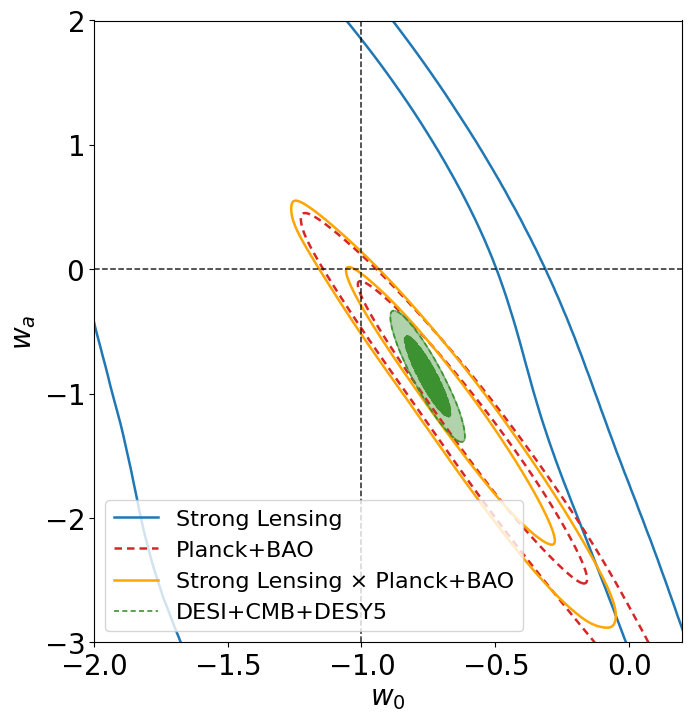

In [2]:
# w0-wa overlay using local SL npz + Planck+BAO + DESI+CMB+DESY5
import os
import numpy as np
from scipy.stats import gaussian_kde
from getdist.mcsamples import MCSamples, loadMCSamples
from getdist import plots

# ---------------- local SL from npz (keep omegam,w0,wa) ----------------
npz_path = '/home/geng/Codes/sgl_cosmo/jax01/output/posterior_minimal_chunks_sgl146_w0wa_main.npz'
if not os.path.exists(npz_path):
    raise FileNotFoundError(f'Missing local npz: {npz_path}')

d = np.load(npz_path)
for k in ['Om', 'w0', 'wa']:
    if k not in d:
        raise KeyError(f'NPZ missing key: {k}')

SL = MCSamples(
    samples=np.column_stack([d['Om'], d['w0'], d['wa']]),
    names=['omegam', 'w0', 'wa'],
    labels=[r'\Omega_{\rm m}', r'w_0', r'w_a'],
)
SL.label = r'Strong Lensing'

# ---------------- Planck+BAO root auto-resolve ----------------
planck_base_label = 'base_w_wa'
chain_name = 'plikHM_TTTEEE_lowl_lowE_BAO'
_planck_dir_candidates = [
    '/home/geng/Codes/sgl_cosmo/jax01/data/planck_data',
    '/home/geng/Codes/sgl_cosmo/jax01/data',
    '/home/astrodust/SG/sgl_cosmo/GLS_cosmo01/Data',
]

def _resolve_planck_root(base_label, chain_name):
    tried = []
    for d0 in _planck_dir_candidates:
        r1 = os.path.join(d0, base_label, chain_name, f'{base_label}_{chain_name}')
        tried.append(r1)
        if os.path.exists(r1 + '_1.txt') or os.path.exists(r1 + '.paramnames'):
            return r1
        r2 = os.path.join(d0, base_label, chain_name)
        tried.append(r2)
        if os.path.exists(r2 + '_1.txt') or os.path.exists(r2 + '.paramnames'):
            return r2
    raise FileNotFoundError('Planck+BAO chain root not found. Tried:\n' + '\n'.join(tried))

planck_root_bao = _resolve_planck_root(planck_base_label, chain_name)
planck_bao = loadMCSamples(planck_root_bao, settings={'ignore_rows': 0.3}, no_cache=True)

# unify to omegam/w0/wa if needed
P = planck_bao.getParams()
names = {p.name for p in planck_bao.getParamNames().names}
if 'w0' not in names:
    if hasattr(P, 'w'):
        planck_bao.addDerived(P.w, name='w0', label=r'w_0')
    else:
        raise RuntimeError('Planck+BAO chain has no w0/w')
if 'wa' not in names and not hasattr(P, 'wa'):
    raise RuntimeError('Planck+BAO chain has no wa')
if 'omegam' not in names:
    if hasattr(P, 'ombh2') and hasattr(P, 'omch2'):
        if hasattr(P, 'h'):
            planck_bao.addDerived((P.ombh2 + P.omch2)/P.h**2, name='omegam', label=r'\Omega_{\rm m}')
        elif hasattr(P, 'H0'):
            planck_bao.addDerived((P.ombh2 + P.omch2)/(P.H0/100.0)**2, name='omegam', label=r'\Omega_{\rm m}')
try:
    planck_bao.setLabel('omegam', r'\Omega_{\rm m}')
    planck_bao.setLabel('w0', r'w_0')
    planck_bao.setLabel('wa', r'w_a')
except Exception:
    pass
planck_bao.label = r'Planck+BAO'

# ---------------- DESI+CMB+DESY5 gaussian approx ----------------
mu_desi = (-0.752, -0.86)   # (w0, wa)
sigma_desi = (0.057, 0.215)
rho_desi = -0.90

def gaussian_to_mcsamples_w0wa(mu, sigmas, rho, nsamp=200000, seed=123, label=r'DESI+CMB+DESY5'):
    rng = np.random.default_rng(seed)
    s0, sa = sigmas
    cov = np.array([[s0**2, rho*s0*sa], [rho*s0*sa, sa**2]], dtype=float)
    samples = rng.multivariate_normal(mean=mu, cov=cov, size=nsamp)
    m = MCSamples(samples=samples, names=['w0','wa'], labels=[r'w_0', r'w_a'])
    m.label = label
    return m

DESI_CMB_DESY5 = gaussian_to_mcsamples_w0wa(mu_desi, sigma_desi, rho_desi)

# ---------------- Joint: reweight in 3D (omegam,w0,wa), plot in 2D (w0,wa) ----------------
_ALIAS = {
    'omegam': ['omegam', 'Om', 'om', 'Omega_m', 'OmegaM', 'omm'],
    'w0': ['w0', 'w', 'w_0'],
    'wa': ['wa', 'w_a', 'wprime', 'w_a_cpl'],
}

def _get_param_with_alias(mcs, name):
    P = mcs.getParams()
    for n in _ALIAS.get(name, [name]):
        if hasattr(P, n):
            arr = np.asarray(getattr(P, n), float)
            if arr.size > 0:
                return arr
    return None

def _extract_named(mcs, names=('omegam','w0','wa')):
    cols = []
    for nm in names:
        arr = _get_param_with_alias(mcs, nm)
        if arr is None:
            raise RuntimeError(f'Missing required parameter {nm} in {getattr(mcs, "label", "mcs")}')
        cols.append(arr)
    return np.vstack(cols).T

def make_joint_by_kde_3d(base_mcs, ref_mcs, label, bw='scott', names=('omegam','w0','wa')):
    base_full = _extract_named(base_mcs, names)
    ref_full = _extract_named(ref_mcs, names)
    w_base = base_mcs.weights if base_mcs.weights is not None else np.ones(base_full.shape[0])
    kde = gaussian_kde(ref_full.T, bw_method=bw)
    dens = np.clip(kde(base_full.T), 1e-300, None)
    w_joint = w_base * dens
    # keep omegam,w0,wa in joint object (no clipping to only w0,wa)
    joint = MCSamples(
        samples=base_full,
        names=['omegam','w0','wa'],
        labels=[r'\Omega_{\rm m}', r'w_0', r'w_a'],
        weights=w_joint,
    )
    joint.label = label
    return joint

SLxPlanckBAO = make_joint_by_kde_3d(
    base_mcs=planck_bao,
    ref_mcs=SL,
    label=r'Strong Lensing × Planck+BAO',
    bw='scott',
    names=('omegam','w0','wa'),
)

# ---------------- plot requested sets (w0-wa plane) ----------------
plot_samples = [SL, planck_bao, SLxPlanckBAO, DESI_CMB_DESY5]
legend_labels = [s.label for s in plot_samples]
COL_SL = '#1f77b4'
COL_PLANCK_BAO = '#d62728'
COL_JOINT = 'orange'
COL_DESI = '#3c9130'

line_args = [
    {'ls':'-',  'lw':1.8},  # SL
    {'ls':'--', 'lw':1.8},  # Planck+BAO
    {'ls':'-',  'lw':1.8},  # SL+Planck+BAO
    {'ls':'--', 'lw':1.2},  # DESI outline
]

g = plots.get_subplot_plotter(width_inch=7.2)
g.settings.num_plot_contours = 2
g.settings.axes_fontsize = 20
g.settings.legend_fontsize = 16

g.plot_2d(
    plot_samples,
    ['w0','wa'],
    filled=False,
    colors=[COL_SL, COL_PLANCK_BAO, COL_JOINT, COL_DESI],
    line_args=line_args,
    legend_labels=None,
)
# fill DESI only
g.plot_2d(DESI_CMB_DESY5, ['w0','wa'], filled=True, colors=[COL_DESI], add_legend_proxy=False, alpha=0.30)

ax = g.subplots[0,0]
ax.set_ylim(-3.0, 2.0)
ax.set_xlim(-2.0, 0.2)
ax.set_xlabel(r'$w_0$', fontsize=20)
ax.set_ylabel(r'$w_a$', fontsize=20)
ax.axvline(-1.0, ls='--', lw=1.1, color='k', alpha=0.85)
ax.axhline(0.0,  ls='--', lw=1.1, color='k', alpha=0.85)

g.add_legend(legend_labels, legend_loc='lower left', colored_text=False)

out = '/home/geng/Codes/sgl_cosmo/jax01/joint_plots/joint3D_w0_wa_SL_DESI_joint_with_DESI_CMB_DESY5.png'
g.export(out)
print(f'Saved: {out}')


In [2]:
# Stats for 4 sets: print omegam, w0, wa
import numpy as np
from scipy.stats import gaussian_kde

# weighted helpers

def _normalize_weights(w):
    if w is None:
        return None
    w = np.asarray(w, float)
    s = np.sum(w)
    if s <= 0 or not np.isfinite(s):
        return None
    return w / s

def _wq(x, q, w=None):
    x = np.asarray(x, float)
    if w is None:
        return float(np.quantile(x, q))
    w = np.asarray(w, float)
    s = np.argsort(x)
    xs, ws = x[s], w[s]
    cdf = np.cumsum(ws) / np.sum(ws)
    return float(np.interp(q, cdf, xs))

def _peak(x, w=None, n=2048):
    x = np.asarray(x, float)
    xmin, xmax = np.min(x), np.max(x)
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        return float(np.median(x))
    grid = np.linspace(xmin, xmax, n)
    kde = gaussian_kde(x, weights=_normalize_weights(w)) if w is not None else gaussian_kde(x)
    dens = kde(grid)
    return float(grid[np.argmax(dens)])

def summarize_2d_mcs(mcs, names=('omegam','w0','wa')):
    w = None if mcs.weights is None else np.asarray(mcs.weights, float)
    out = {}
    for nm in names:
        arr = _get_param_with_alias(mcs, nm)
        if arr is None:
            out[nm] = None
            continue
        q16 = _wq(arr, 0.16, w)
        q50 = _wq(arr, 0.50, w)
        q84 = _wq(arr, 0.84, w)
        mu = float(np.average(arr, weights=w)) if w is not None else float(np.mean(arr))
        out[nm] = {
            'peak': _peak(arr, w),
            'median': q50,
            'q16': q16,
            'q84': q84,
            'mean': mu,
            'minus': q50 - q16,
            'plus': q84 - q50,
        }
    return out



_ALIAS = {
    'omegam': ['omegam', 'Om', 'om', 'Omega_m', 'OmegaM', 'omm'],
    'w0': ['w0', 'w', 'w_0'],
    'wa': ['wa', 'w_a', 'wprime', 'w_a_cpl'],
}

def _get_param_with_alias(mcs, name):
    P = mcs.getParams()
    candidates = _ALIAS.get(name, [name])
    for n in candidates:
        if hasattr(P, n):
            arr = np.asarray(getattr(P, n), float)
            if arr.size > 0:
                return arr
    return None

def print_summary(tag, s):
    print(f'\n=== {tag} ===')
    for nm in ('omegam','w0','wa'):
        v = s.get(nm, None)
        if v is None:
            print(f"{nm:7s}: N/A")
            continue
        print(
            f"{nm:7s}: peak={v['peak']:.6f} | "
            f"median={v['median']:.6f} (-{v['minus']:.6f}, +{v['plus']:.6f}) | "
            f"mean={v['mean']:.6f}"
        )

stats_targets = [
    (SL.label, SL),
    (planck_bao.label, planck_bao),
    (SLxPlanckBAO.label, SLxPlanckBAO),
    (DESI_CMB_DESY5.label, DESI_CMB_DESY5),
]

for tag, mcs in stats_targets:
    print_summary(tag, summarize_2d_mcs(mcs, names=('omegam','w0','wa')))



=== Strong Lensing ===
omegam : peak=0.347883 | median=0.354422 (-0.099008, +0.098679) | mean=0.353359
w0     : peak=-0.918533 | median=-1.227577 (-1.212732, +0.794684) | mean=-1.387260
wa     : peak=-4.785405 | median=-1.549109 (-3.057875, +3.447174) | mean=-1.323704

=== Planck+BAO ===
omegam : peak=0.339102 | median=0.341583 (-0.025510, +0.025946) | mean=0.341667
w0     : peak=-0.558300 | median=-0.572602 (-0.277756, +0.271223) | mean=-0.577797
wa     : peak=-1.165536 | median=-1.312623 (-0.798493, +0.774770) | mean=-1.316303

=== Strong Lensing + Planck+BAO ===
omegam : peak=0.331052 | median=0.333598 (-0.022647, +0.024218) | mean=0.334196
w0     : peak=-0.684590 | median=-0.654555 (-0.247960, +0.263171) | mean=-0.650229
wa     : peak=-1.033461 | median=-1.105697 (-0.784501, +0.696294) | mean=-1.139424

=== DESI+CMB+DESY5 ===
omegam : N/A
w0     : peak=-0.751132 | median=-0.752002 (-0.056757, +0.056653) | mean=-0.752075
wa     : peak=-0.853210 | median=-0.859689 (-0.214287, +0.213